In [1]:
# Task 1 - Load dataset
import pandas as pd

df = pd.read_csv(r"C:\Users\safin\Desktop\telecom_churn.csv")

#first 5 rows
df.head()

#Data types
print(df.dtypes)

#shape
print(df.shape)

customer_id            int64
gender                object
senior_citizen        object
partner               object
dependents            object
tenure               float64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges       object
total_charges         object
signup_date           object
churn                 object
internal_flag         object
dtype: object
(20030, 23)


In [28]:
#convert object columns to numeric
df["monthly_charges"] = pd.to_numeric(df["monthly_charges"], errors="coerce")
df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce") 

# Task 2 - Count of missing values
null_count = df.isnull().sum()

# Percentage of missing values
null_percentage = (df.isnull().sum()/df.shape[0])*100

# Create a table
null_table = pd.DataFrame({
    "null count": null_count,
    "null_percentage": null_percentage
})
print(null_table)

                   null count  null_percentage
customer_id                 0              0.0
gender                      0              0.0
senior_citizen              0              0.0
partner                     0              0.0
dependents                  0              0.0
tenure                      0              0.0
phone_service               0              0.0
multiple_lines              0              0.0
internet_service            0              0.0
online_security             0              0.0
online_backup               0              0.0
device_protection           0              0.0
tech_support                0              0.0
streaming_tv                0              0.0
streaming_movies            0              0.0
contract                    0              0.0
paperless_billing           0              0.0
payment_method              0              0.0
monthly_charges             0              0.0
total_charges               0              0.0
signup_date  

In [27]:
# Task 2 - find columns with more than 20% missing values


more_than_20 = null_table[null_table["null_percentage"]>20]
print("columns with more than 20% null values:")
print(more_than_20)

#fill numeric columns having less than 20% missing values with the median
for col in df.select_dtypes(include=["int64","float64"]).columns:
    if null_percentage[col]<20:
       df[col] = df[col].fillna(df[col].median())
#check remaining null values
print(df.isnull().sum())

null_percentage = (df.isnull().sum() / len(df)) * 100

null_percentage[null_percentage > 0]
print(df.dtypes)

columns with more than 20% null values:
Empty DataFrame
Columns: [null count, null_percentage]
Index: []
customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
signup_date          0
churn                0
internal_flag        0
dtype: int64
customer_id                   int64
gender                     category
senior_citizen              float64
partner                      object
dependents                   object
tenure                      float64
phone_service                object
multiple_lines               object
internet_service             object
online_security              

In [4]:
# Task 3 - Count duplicate rows
duplicates = df.duplicated().sum()
print("duplicate rows:", duplicates)

#Rows before removing duplicates
rows_before = df.shape[0]

#Removing duplicates
df = df.drop_duplicates()

#Rows after removing duplicates
rows_after = df.shape[0]
print("Rows removed", rows_before - rows_after)

# Check dataset shape
print("New Shape:", df.shape)

#check null percentages again
new_null_percentage = (df.isnull()/df.shape[0]) * 100
print(new_null_percentage)





duplicate rows: 20
Rows removed 20
New Shape: (20010, 23)
       customer_id  gender  senior_citizen  partner  dependents  tenure  \
0              0.0     0.0             0.0      0.0         0.0     0.0   
1              0.0     0.0             0.0      0.0         0.0     0.0   
2              0.0     0.0             0.0      0.0         0.0     0.0   
3              0.0     0.0             0.0      0.0         0.0     0.0   
4              0.0     0.0             0.0      0.0         0.0     0.0   
...            ...     ...             ...      ...         ...     ...   
20025          0.0     0.0             0.0      0.0         0.0     0.0   
20026          0.0     0.0             0.0      0.0         0.0     0.0   
20027          0.0     0.0             0.0      0.0         0.0     0.0   
20028          0.0     0.0             0.0      0.0         0.0     0.0   
20029          0.0     0.0             0.0      0.0         0.0     0.0   

       phone_service  multiple_lines  int

In [5]:
# Task 4 - Datatype correction
# memory usage before conversation
before_memory = df.memory_usage(deep=True).sum()
print("Memory usage before conversation:", before_memory, "bytes")

#convert object columns to numeric
df["monthly_charges"] = pd.to_numeric(df["monthly_charges"], errors="coerce")
df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")

#convert senior citizen to integer

df["senior_citizen"] = pd.to_numeric(df["senior_citizen"],errors="coerce")

#convert signup_date to datetime
df["signup_date"] = pd.to_datetime(df["signup_date"],errors="coerce")

#convert gender to category
df["gender"] = df["gender"].astype("category")
print(df.dtypes)

#memory usage after conversation
after_memory = df.memory_usage(deep=True).sum()
print("Memory usage after conversation:", after_memory, "bytes")
print("Memory saved:", before_memory - after_memory, "bytes")
print(df.dtypes)

Memory usage before conversation: 23166145 bytes
customer_id                   int64
gender                     category
senior_citizen              float64
partner                      object
dependents                   object
tenure                      float64
phone_service                object
multiple_lines               object
internet_service             object
online_security              object
online_backup                object
device_protection            object
tech_support                 object
streaming_tv                 object
streaming_movies             object
contract                     object
paperless_billing            object
payment_method               object
monthly_charges             float64
total_charges               float64
signup_date          datetime64[ns]
churn                        object
internal_flag                object
dtype: object
Memory usage after conversation: 18447551 bytes
Memory saved: 4718594 bytes
customer_id                   int

In [6]:
#Task: 5
#descriptive statistics for numeric columns
print(df.describe())


        customer_id  senior_citizen        tenure  monthly_charges  \
count  20010.000000    17061.000000  20010.000000     17122.000000   
mean   11001.112894        0.174198     36.018591        75.335998   
min     1001.000000        0.000000      0.000000        20.020000   
25%     6001.250000        0.000000     17.000000        45.100000   
50%    11000.500000        0.000000     36.000000        70.260000   
75%    16001.750000        0.000000     54.000000        95.240000   
max    21000.000000        1.000000    198.000000       798.651621   
std     5774.267355        0.379291     22.462415        61.245798   

       total_charges                    signup_date  
count   18882.000000                          20010  
mean     4035.911543  2022-07-03 01:31:23.658171136  
min       100.470000            2020-01-01 00:00:00  
25%      2056.005000            2021-04-02 00:00:00  
50%      4031.745000            2022-07-05 00:00:00  
75%      6026.480000            2023-10-01 00

In [7]:
#Task: 5
#descriptive statistics for numeric columns
skewness = df.select_dtypes(include=["int64", "float64"]).skew()
print(skewness)
highest_skew = skewness.abs().idxmax()
print("Column with highest absolute skewness:", highest_skew)
print("skewness value:", skewness[highest_skew])

customer_id       -0.000075
senior_citizen     1.718151
tenure             0.816940
monthly_charges    7.003768
total_charges      0.002756
dtype: float64
Column with highest absolute skewness: monthly_charges
skewness value: 7.003767990420948


In [8]:
#Task 6 – Outlier Detection with IQR:
col = "monthly_charges"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[col]< lower_bound) |(df[col]> upper_bound)]

print("column:", col)
print("Q1:", Q1)
print("Q3", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))

column: monthly_charges
Q1: 45.1
Q3 95.24
IQR: 50.13999999999999
Lower bound: -30.109999999999992
Upper Bound: 170.45
Number of outliers: 196


In [9]:
#Task 6 – Outlier Detection with IQR:
col = "total_charges"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print("Column:", col)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

Column: total_charges
Q1: 2056.005
Q3: 6026.4800000000005
IQR: 3970.4750000000004
Lower Bound: -3899.7075000000004
Upper Bound: 11982.192500000001
Number of Outliers: 0


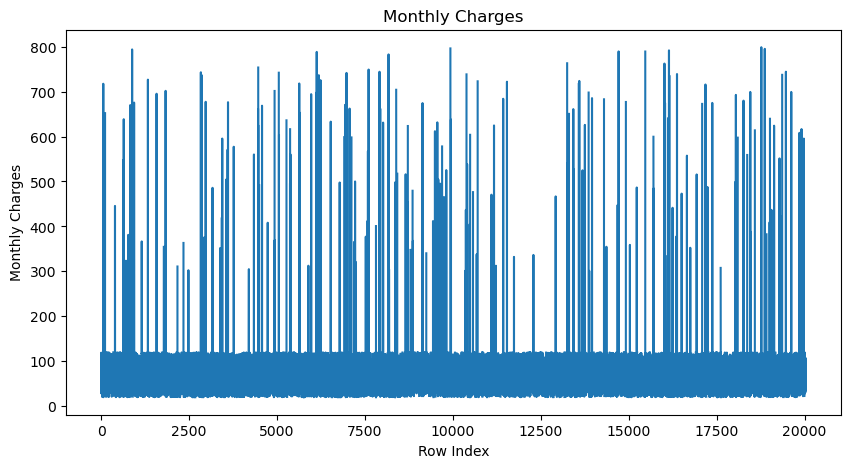

In [10]:
# Task 7 - Line plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df["monthly_charges"])
plt.title("Monthly Charges")
plt.xlabel("Row Index")
plt.ylabel("Monthly Charges")
plt.show()


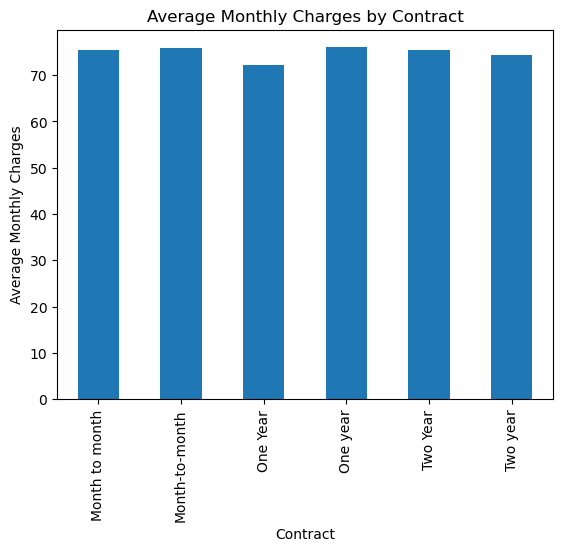

In [11]:
# Task 7 - Bar Chart
df.groupby("contract")["monthly_charges"].mean().plot.bar()

plt.title("Average Monthly Charges by Contract")
plt.xlabel("Contract")
plt.ylabel("Average Monthly Charges")
plt.show()

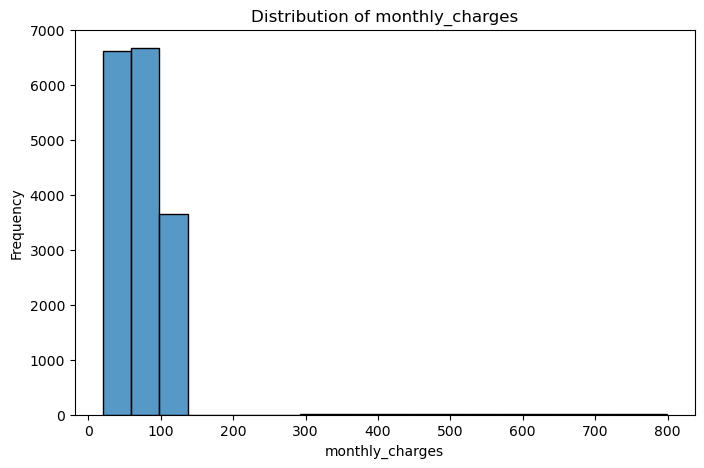

In [12]:
# Task 7 - Histogram
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df["monthly_charges"], bins=20)

plt.title("Distribution of monthly_charges")
plt.xlabel("monthly_charges")
plt.ylabel("Frequency")
plt.show()

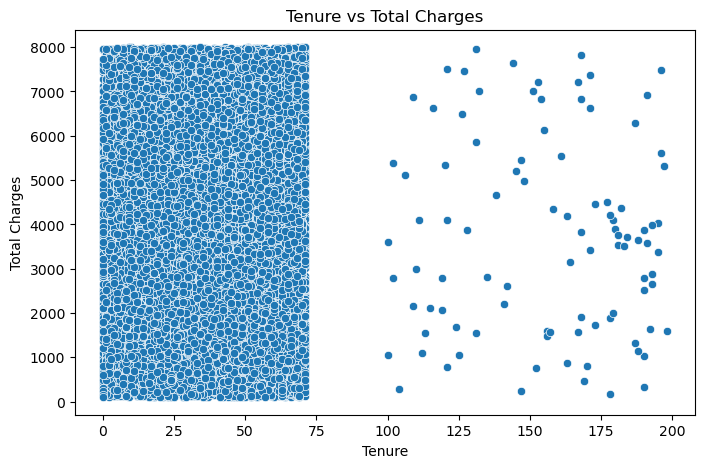

In [13]:
# Task 7 - Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(x="tenure", y="total_charges", data=df)

plt.title("Tenure vs Total Charges")
plt.xlabel("Tenure")
plt.ylabel("Total Charges")
plt.show()

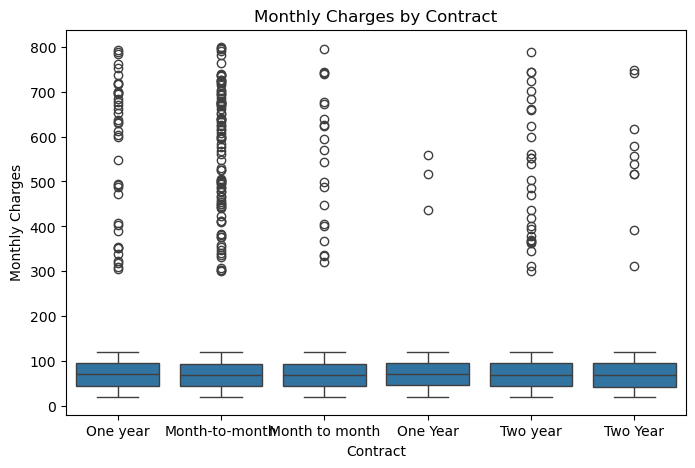

In [14]:
# Task 7 - Box Plot
plt.figure(figsize=(8,5))
sns.boxplot(x="contract", y="monthly_charges", data=df)

plt.title("Monthly Charges by Contract")
plt.xlabel("Contract")
plt.ylabel("Monthly Charges")
plt.show()

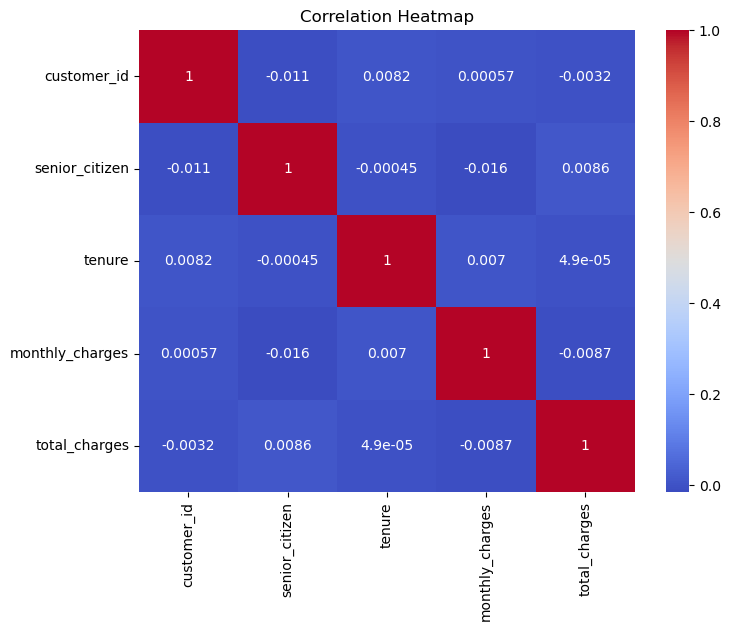

In [15]:
# Task 8 - correlation Heat map
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [16]:
# Task 8: Highest Absolute Correlation
corr_matrix = corr.abs()

corr_matrix.values[[range(len(corr_matrix))]*2] = 0

highest = corr_matrix.unstack().idxmax()
value = corr_matrix.unstack().max()

print("Highest Correlation Pair:", highest)
print("Correlation Value:", value)

Highest Correlation Pair: ('customer_id', 'customer_id')
Correlation Value: 0.0


In [17]:
# Task 9(a)

# Find the two numeric columns with the highest absolute skewness
skewness = df.select_dtypes(include=["int64", "float64"]).skew()
top2 = skewness.abs().sort_values(ascending=False).head(2)

print("Top 2 skewed columns:")
print(top2)

# Print mean and median before imputation
for col in top2.index:
    print(f"\nColumn: {col}")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())

# Impute missing values using the median
for col in top2.index:
    df[col] = df[col].fillna(df[col].median())

# Confirm no nulls remain in these columns
print("\nNull values after imputation:")
print(df[top2.index].isnull().sum())

Top 2 skewed columns:
monthly_charges    7.003768
senior_citizen     1.718151
dtype: float64

Column: monthly_charges
Mean: 75.33599761165638
Median: 70.26

Column: senior_citizen
Mean: 0.17419846433386085
Median: 0.0

Null values after imputation:
monthly_charges    0
senior_citizen     0
dtype: int64


In [18]:
# Task 9.b.1 - Pearson Correlation Matrix

pearson = df.corr(numeric_only=True)

print("Pearson Correlation Matrix")
print(pearson)

Pearson Correlation Matrix
                 customer_id  senior_citizen    tenure  monthly_charges  \
customer_id         1.000000       -0.010182  0.008200         0.000850   
senior_citizen     -0.010182        1.000000  0.000712        -0.014839   
tenure              0.008200        0.000712  1.000000         0.006537   
monthly_charges     0.000850       -0.014839  0.006537         1.000000   
total_charges      -0.003229        0.008637  0.000049        -0.007939   

                 total_charges  
customer_id          -0.003229  
senior_citizen        0.008637  
tenure                0.000049  
monthly_charges      -0.007939  
total_charges         1.000000  


In [19]:
# Task 9.b.2 - Spearman Correlation Matrix

spearman = df.corr(method="spearman", numeric_only=True)

print("Spearman Correlation Matrix")
print(spearman)

Spearman Correlation Matrix
                 customer_id  senior_citizen    tenure  monthly_charges  \
customer_id         1.000000       -0.010182  0.006686         0.004420   
senior_citizen     -0.010182        1.000000  0.001128        -0.013196   
tenure              0.006686        0.001128  1.000000        -0.000923   
monthly_charges     0.004420       -0.013196 -0.000923         1.000000   
total_charges      -0.003250        0.008644  0.002797        -0.011254   

                 total_charges  
customer_id          -0.003250  
senior_citizen        0.008644  
tenure                0.002797  
monthly_charges      -0.011254  
total_charges         1.000000  


In [20]:
# Task 9.b.3 - Difference between Spearman and Pearson

difference = (spearman - pearson).abs()

print("Difference Matrix")
print(difference)

Difference Matrix
                  customer_id  senior_citizen    tenure  monthly_charges  \
customer_id      0.000000e+00    1.525024e-07  0.001514         0.003570   
senior_citizen   1.525024e-07    0.000000e+00  0.000416         0.001643   
tenure           1.514405e-03    4.164724e-04  0.000000         0.007460   
monthly_charges  3.569700e-03    1.642874e-03  0.007460         0.000000   
total_charges    2.099280e-05    6.687335e-06  0.002748         0.003315   

                 total_charges  
customer_id           0.000021  
senior_citizen        0.000007  
tenure                0.002748  
monthly_charges       0.003315  
total_charges         0.000000  


In [21]:
import numpy as np

# Task 9.b.4 Remove duplicate pairs and diagonal
mask = np.triu(np.ones(difference.shape), k=1).astype(bool)

top3 = difference.where(mask).stack().sort_values(ascending=False).head(3)

print("Top 3 Column Pairs with Largest Difference")
print(top3)

Top 3 Column Pairs with Largest Difference
tenure           monthly_charges    0.007460
customer_id      monthly_charges    0.003570
monthly_charges  total_charges      0.003315
dtype: float64


In [22]:
# 9.c Choose one categorical column and one numeric column
categorical_col = "contract"
numeric_col = "monthly_charges"

# Grouped aggregation
group_stats = df.groupby(categorical_col)[numeric_col].agg(['mean', 'std', 'count'])

print(group_stats)

# Find highest mean group
highest_mean_group = group_stats['mean'].idxmax()
highest_mean = group_stats['mean'].max()

# Find highest standard deviation group
highest_std_group = group_stats['std'].idxmax()
highest_std = group_stats['std'].max()

# Ratio of highest mean to lowest mean
lowest_mean = group_stats['mean'].min()
ratio = highest_mean / lowest_mean

print("\nGroup with highest mean:", highest_mean_group)
print("Highest mean:", highest_mean)

print("\nGroup with highest standard deviation:", highest_std_group)
print("Highest standard deviation:", highest_std)

print("\nHighest Mean / Lowest Mean Ratio:", ratio)

                     mean        std  count
contract                                   
Month to month  74.562608  57.996094   1977
Month-to-month  74.946832  58.297520   9017
One Year        71.795765  35.273838   1019
One year        75.199820  59.127458   3999
Two Year        74.653318  58.426339    921
Two year        73.762855  52.875965   3077

Group with highest mean: One year
Highest mean: 75.199819640087

Group with highest standard deviation: One year
Highest standard deviation: 59.12745828383066

Highest Mean / Lowest Mean Ratio: 1.047413030220875


In [23]:
df.to_csv("cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully as 'cleaned_data.csv'")

Cleaned dataset saved successfully as 'cleaned_data.csv'


In [24]:
df.to_csv("cleaned_data.csv", index=False)
print("Saved successfully!")


Saved successfully!
